In [1]:
from qklearn.cluster import ConstrainedClustering
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

## Preparing the dataset

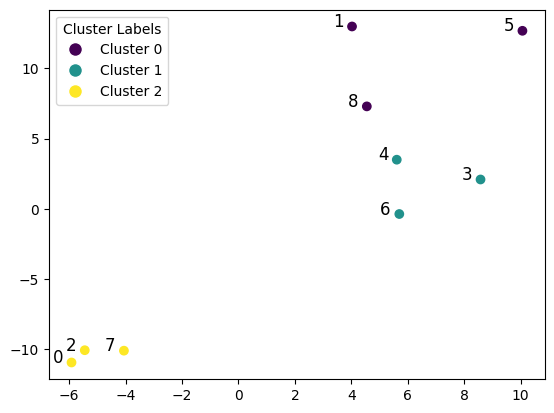

In [2]:
def get_artificial_data(n_clusters, n_points):
    data, labels = make_blobs(random_state=8,
                                    n_samples=n_points,
                                    n_features=2, 
                                    cluster_std=1.5,
                                    centers=n_clusters)
    return data, labels

data, labels_origin = get_artificial_data(n_clusters=3, n_points=9)

# 可視化
# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_origin)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_origin):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

## Solver client configuration

In [3]:
# In the case of Fixstars Amplify
from amplify import FixstarsClient
from datetime import timedelta
from qklearn.utils import read_token

client = FixstarsClient()
client.token = read_token("Fixstars")
client.parameters.timeout = timedelta(milliseconds=1000)

## Perform clustering with must-link constraints

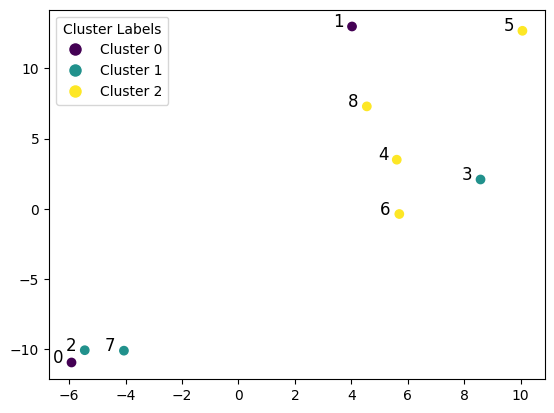

In [4]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_must_link_to_qubo([(0,1), (2,3), (4,5)])  # set must-link constraints
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

## Perform clustering with only one must-link constraint
This test succeeded in all combinations.

In [7]:
import itertools

success = True
samples = [i for i in range(9)]

for pair in itertools.combinations(samples, 2):  # try all combinations
    ccl = ConstrainedClustering(n_clusters=3)
    ccl.fit(data)
    ccl.add_must_link_to_qubo([pair])
    labels_ccl = ccl.predict(client)
    print(f"must_link = {pair} : labels = {labels_ccl}")

    if len(set(labels_ccl)) != 3:
        success = False
        break

if success:
    print("+++ This test succeeded in all combinations. +++")
else:
    # plot labels
    scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
    for i, (x, y) in enumerate(data):
        plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

    # show legend for each label
    handles = []
    labels = []
    for label in set(labels_ccl):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                                markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
        labels.append(f'Cluster {label}')
    plt.legend(handles=handles, title="Cluster Labels")
    plt.show()

must_link = (0, 1) : labels = [1, 1, 0, 2, 2, 1, 2, 0, 2]
must_link = (0, 2) : labels = [2, 1, 2, 0, 0, 1, 0, 2, 1]
must_link = (0, 3) : labels = [1, 0, 1, 1, 2, 0, 2, 1, 2]
must_link = (0, 4) : labels = [1, 0, 1, 2, 1, 0, 2, 1, 0]
must_link = (0, 5) : labels = [1, 1, 2, 0, 0, 1, 0, 2, 0]
must_link = (0, 6) : labels = [2, 1, 2, 0, 0, 1, 2, 2, 0]
must_link = (0, 7) : labels = [1, 2, 1, 0, 0, 2, 0, 1, 2]
must_link = (0, 8) : labels = [2, 0, 2, 1, 1, 0, 1, 2, 2]
must_link = (1, 2) : labels = [2, 0, 0, 1, 1, 0, 1, 2, 1]
must_link = (1, 3) : labels = [2, 1, 2, 1, 0, 1, 0, 2, 0]
must_link = (1, 4) : labels = [2, 0, 2, 1, 0, 0, 1, 2, 1]
must_link = (1, 5) : labels = [2, 0, 2, 1, 1, 0, 1, 2, 0]
must_link = (1, 6) : labels = [1, 2, 1, 0, 0, 2, 2, 1, 0]
must_link = (1, 7) : labels = [0, 1, 0, 2, 2, 1, 2, 1, 2]
must_link = (1, 8) : labels = [0, 2, 0, 1, 1, 2, 1, 0, 2]
must_link = (2, 3) : labels = [1, 0, 1, 1, 2, 0, 2, 1, 2]
must_link = (2, 4) : labels = [0, 2, 0, 1, 0, 2, 1, 0, 2]
must_link = (2

## Perform clustering with must-link constraints (set the weight smaller than the default value)
default value of weight = n_samples - n_clusters = 9 - 3 = 6

must_link = [(0, 1), (2, 3), (4, 5)] : labels = [1, 1, 2, 2, 0, 0, 0, 2, 0]


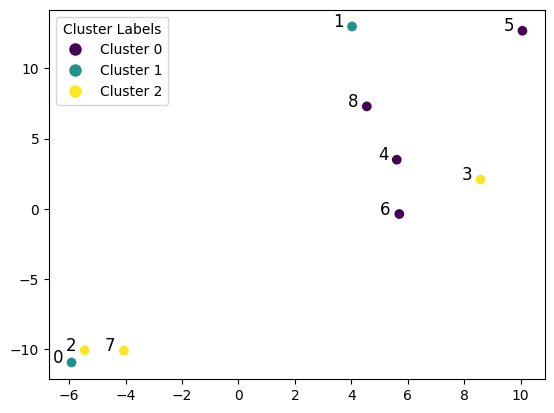

In [6]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)

must_link = [(0,1), (2,3), (4,5)]
weight_must_link = 5.0  # the weight smaller than the default value

ccl.add_must_link_to_qubo(must_link, weight_must_link)
labels_ccl = ccl.predict(client)
print(f"must_link = {must_link} : labels = {labels_ccl}")

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                            markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()